In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount("content")

Mounted at content


In [5]:
pollen = pd.read_csv("/content/content/MyDrive/data_complete.csv")
pollen.head()

,Unnamed: 0,date,File.Name,Dataset,aid,Count,Minimum,Maximum,Range,Mean,...,day,month,year,fyear,ds,logvalue,season,pollen_cat,mintemp_anom,maxtemp_anom
0,1,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,2011,2011,1,1.609438,In season,Moderate,-0.543129,12.156871
1,2,2011-01-02,MOD13Q1_006__250m_16_days_EVI_doy2011001_aid0001,_250m_16_days_EVI,aid0001,593.0,-0.0355,0.5807,"(-0.0355,0.5807)",0.1566,...,2,1,2011,2011,2,1.609438,In season,Moderate,-1.992425,4.107575
2,3,2011-01-03,MOD13Q1_006__250m_16_days_EVI_doy2011001_aid0001,_250m_16_days_EVI,aid0001,593.0,-0.0355,0.5807,"(-0.0355,0.5807)",0.1566,...,3,1,2011,2011,3,0.000000,In season,Very low,0.059490,16.059490
3,4,2011-01-04,MOD13Q1_006__250m_16_days_EVI_doy2011001_aid0001,_250m_16_days_EVI,aid0001,593.0,-0.0355,0.5807,"(-0.0355,0.5807)",0.1566,...,4,1,2011,2011,4,2.564949,In season,High,1.012645,17.412645
4,5,2011-01-05,MOD13Q1_006__250m_16_days_EVI_doy2011001_aid0001,_250m_16_days_EVI,aid0001,593.0,-0.0355,0.5807,"(-0.0355,0.5807)",0.1566,...,5,1,2011,2011,5,0.693147,In season,Low,0.967067,17.967067


In [6]:
pollen.shape

(1953, 37)

In [7]:
pollen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1953 entries, 0 to 1952
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1953 non-null   int64  
 1   date                1953 non-null   object 
 2   File.Name           1952 non-null   object 
 3   Dataset             1952 non-null   object 
 4   aid                 1952 non-null   object 
 5   Count               1952 non-null   float64
 6   Minimum             1952 non-null   float64
 7   Maximum             1952 non-null   float64
 8   Range               1952 non-null   object 
 9   Mean                1952 non-null   float64
 10  Standard.Deviation  1952 non-null   float64
 11  Variance            1952 non-null   float64
 12  Upper.Quartile      1952 non-null   float64
 13  Upper.1.5.IQR       1952 non-null   float64
 14  veg_index           1952 non-null   float64
 15  Lower.1.5.IQR       1952 non-null   float64
 16  Lower.

In [8]:
pollen.duplicated().sum()

np.int64(0)

In [9]:
pollen.isnull().sum()

,0
Unnamed: 0,0
date,0
File.Name,1
Dataset,1
aid,1
Count,1
Minimum,1
Maximum,1
Range,1
Mean,1


In [13]:
#we have 37 columns, but for this analysis we need some of them, not all. so we drop irrelevant columns
cols_to_drop = ["maxtemp_anom","mintemp_anom","ds","fyear","day","visibility","wind_dir","max_temp","min_temp",
                "File.Name","Dataset","aid","Unnamed: 0",	"Count","Minimum","Maximum","Range","Mean","Standard.Deviation",
                "Variance","Upper.Quartile","Upper.1.5.IQR","veg_index","Lower.1.5.IQR","Lower.Quartile"]
df = pollen.drop(columns= cols_to_drop)

print(df.columns)

Index(['date', 'Temperature', 'Dew.Point', 'humid', 'rain', 'wind_speed',
       'pollen_count', 'month', 'year', 'logvalue', 'season', 'pollen_cat'],
      dtype='object')


In [14]:
df.shape # now we 12 columns from 37

(1953, 12)

In [15]:
df.isnull().sum() # when we drop the irrelevant columns, null values also removed

,0
date,0
Temperature,0
Dew.Point,0
humid,0
rain,0
wind_speed,0
pollen_count,0
month,0
year,0
logvalue,0


In [16]:
df.head()

,date,Temperature,Dew.Point,humid,rain,wind_speed,pollen_count,month,year,logvalue,season,pollen_cat
0,2011-01-01,21.0,17.2,80.88,12.46,33.5,4,1,2011,1.609438,In season,Moderate
1,2011-01-02,17.9,16.3,91.10,4.30,40.6,4,1,2011,1.609438,In season,Moderate
2,2011-01-03,24.4,14.6,56.65,0.00,40.6,0,1,2011,0.000000,In season,Very low
3,2011-01-04,25.7,15.7,57.91,0.00,30.3,12,1,2011,2.564949,In season,High
4,2011-01-05,25.9,16.8,60.23,0.00,27.7,1,1,2011,0.693147,In season,Low


In [17]:
#for changing the date in to datetime, first check
df['date'].dtype

dtype('O')

In [18]:
#convert date
df['date'] = pd.to_datetime(df['date'])

#renaming logvalue in to pollen level, for clarity
df = df.rename(columns={
    "logvalue":"pollen_level"
})

df.head()

,date,Temperature,Dew.Point,humid,rain,wind_speed,pollen_count,month,year,pollen_level,season,pollen_cat
0,2011-01-01,21.0,17.2,80.88,12.46,33.5,4,1,2011,1.609438,In season,Moderate
1,2011-01-02,17.9,16.3,91.10,4.30,40.6,4,1,2011,1.609438,In season,Moderate
2,2011-01-03,24.4,14.6,56.65,0.00,40.6,0,1,2011,0.000000,In season,Very low
3,2011-01-04,25.7,15.7,57.91,0.00,30.3,12,1,2011,2.564949,In season,High
4,2011-01-05,25.9,16.8,60.23,0.00,27.7,1,1,2011,0.693147,In season,Low


In [19]:
df['date'].dtype

dtype('<M8[ns]')

In [21]:
#Extract Year and month for easy filturing
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

#sort by date to ensure time series analysis
df = df.sort_values('date')

The project needs two datasets, one pollen index and clinical. Since getting clinical data for this case is hard. Generating synthetic data is an option

In [28]:
#copy the pollen data, first
clinic_df = df.copy()
np.random.seed(42)# in order to use the generated number, to not randomly generate another when running it again

#normalize some variables
pollen = clinic_df["pollen_count"]
wind = clinic_df["wind_speed"]
humid = clinic_df["humid"]
rain = clinic_df["rain"]

#creating data for clinical visits
#respiratory visits(allergeis), assume 5 patients come to clinic (constant)
clinic_df["respiratory_visits"] = (
    5 +
    0.03 * pollen +
    0.5 * wind +
    -0.2 * humid +
    -0.3 * rain +

    np.random.normal(0, 1.5, len(clinic_df)) # adding some noise on the data, for the data to have dynamic/different changes
)

#Immunity visits (less sensetive)
clinic_df["immunity_visits"] = (
    4 +
    0.02 * pollen +
    0.3 * humid +
    0.1 * wind +
    np.random.normal(0,1.2, len(clinic_df))
)

#Wellness  visits (stable baseline demand)
clinic_df["wellness_visits"] = (
    6 +
   0.5 * np.sin(clinic_df["month"]*2 * np.pi /12) +
    np.random.normal(0,1, len(clinic_df))
)

In [29]:
#assume some prices for each type of visits
clinic_df["revenue"] = (
    clinic_df["respiratory_visits"] * 120 +
    clinic_df["immunity_visits"] * 100 +
    clinic_df["wellness_visits"] * 80
)

In [31]:
cols = ["respiratory_visits","immunity_visits","wellness_visits"]

for col in cols:
  clinic_df[col] = clinic_df[col].apply(lambda x: max(0, x))

In [32]:
clinic_df.head()

,date,Temperature,Dew.Point,humid,rain,wind_speed,pollen_count,month,year,pollen_level,season,pollen_cat,respiratory_visits,immunity_visits,wellness_visits,revenue
0,2011-01-01,21.0,17.2,80.88,12.46,33.5,4,1,2011,1.609438,In season,Moderate,2.701071,30.909480,7.575432,4021.111156
1,2011-01-02,17.9,16.3,91.10,4.30,40.6,4,1,2011,1.609438,In season,Moderate,5.702604,34.755206,4.843185,4547.287870
2,2011-01-03,24.4,14.6,56.65,0.00,40.6,0,1,2011,0.000000,In season,Very low,14.941533,26.704326,6.835904,5010.288844
3,2011-01-04,25.7,15.7,57.91,0.00,30.3,12,1,2011,2.564949,In season,High,11.212545,22.080191,5.513230,3994.582858
4,2011-01-05,25.9,16.8,60.23,0.00,27.7,1,1,2011,0.693147,In season,Low,6.482770,28.624298,4.834733,4027.140841


In [33]:
clinic_df.shape

(1953, 16)

In [34]:
clinic_df.to_csv("Environmental Impact Analysis for Holistic Health Revenue Optimization.csv", index=False)

Exploratory Data Analysis

trends

correlations

lag analysis

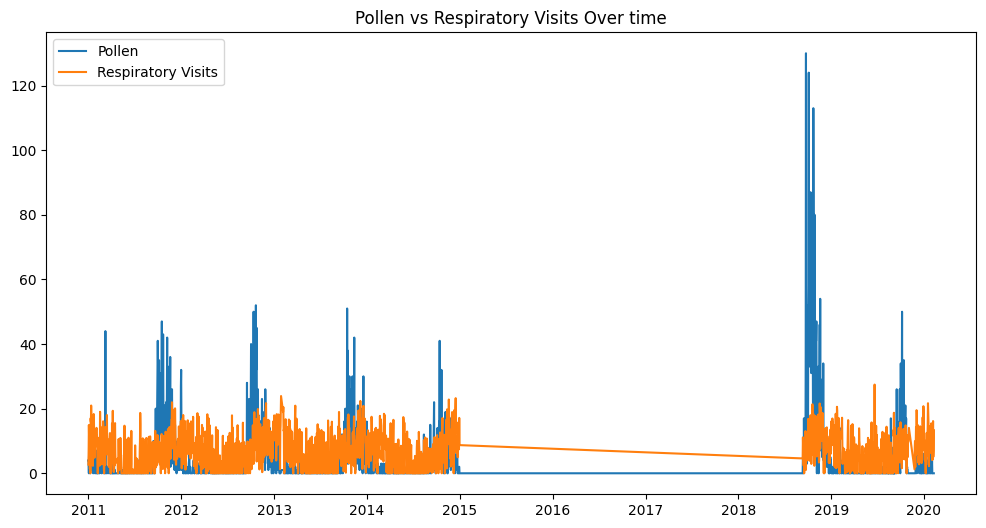

In [35]:
#Time series analysis to understand how environmental factors affect clinical demand
plt.figure(figsize=(12,6))
plt.plot(clinic_df['date'], clinic_df['pollen_count'], label="Pollen")
plt.plot(clinic_df['date'], clinic_df['respiratory_visits'], label="Respiratory Visits")
plt.legend()
plt.title("Pollen vs Respiratory Visits Over time")
plt.show()


Respiratory visits closely follows pollen trends over time. When pollen increases visits increases when pollen is stable visits are stabel

In [36]:
#correlation analysis
clinic_df.corr(numeric_only=True)

,Temperature,Dew.Point,humid,rain,wind_speed,pollen_count,month,year,pollen_level,respiratory_visits,immunity_visits,wellness_visits,revenue
Temperature,1.000000,0.777661,-0.408023,-0.258407,0.299018,0.142825,-0.256199,0.100570,0.270400,0.428210,-0.265067,0.182104,0.344276
Dew.Point,0.777661,1.000000,0.243541,-0.100432,0.277501,-0.018723,-0.353088,-0.019895,0.072243,0.165378,0.315385,0.197460,0.323134
humid,-0.408023,0.243541,1.000000,0.257599,-0.122480,-0.232396,-0.124908,-0.176554,-0.313728,-0.477160,0.864725,0.002450,-0.121182
rain,-0.258407,-0.100432,0.257599,1.000000,0.071104,-0.103366,0.009275,-0.035435,-0.165439,-0.203767,0.248931,-0.045939,-0.175324
wind_speed,0.299018,0.277501,-0.122480,0.071104,1.000000,0.047256,-0.008407,-0.026779,0.130032,0.854947,0.209430,0.012154,0.915284
pollen_count,0.142825,-0.018723,-0.232396,-0.103366,0.047256,1.000000,0.353099,0.074079,0.796367,0.194114,-0.126172,-0.128665,0.126963
month,-0.256199,-0.353088,-0.124908,0.009275,-0.008407,0.353099,1.000000,0.016583,0.440955,0.049977,-0.101376,-0.245426,-0.019070
year,0.100570,-0.019895,-0.176554,-0.035435,-0.026779,0.074079,0.016583,1.000000,0.007049,0.038472,-0.168125,-0.031643,-0.026114
pollen_level,0.270400,0.072243,-0.313728,-0.165439,0.130032,0.796367,0.440955,0.007049,1.000000,0.280750,-0.195423,-0.108365,0.190655
respiratory_visits,0.428210,0.165378,-0.477160,-0.203767,0.854947,0.194114,0.049977,0.038472,0.280750,1.000000,-0.151867,0.016523,0.889470


Check the correlation between, some important elements

pollen-> respiratory_visits ~ 0.19

pollen->revenue = 0.126963

weather(wind_speed, rain, humidity)->respiratory_visits

wind_speed-> respiratory_visits = 0.854947

humidity-> respiratory_visits =  -0.477160

rain-> respiratory_visits = -0.203767


respiratory_visits->revenue = 0.889470

wind_speed -> revenue = 0.915284


In [38]:
#Seasonal trend
clinic_df.groupby("season")[[
    "pollen_count",
    "respiratory_visits",
    "revenue"
]].mean()

,pollen_count,respiratory_visits,revenue
season,,,
In season,9.753363,8.874557,4252.633404
Not in season,0.806786,5.337756,3896.727448


In [40]:
clinic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1953 entries, 0 to 1952
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1953 non-null   datetime64[ns]
 1   Temperature         1953 non-null   float64       
 2   Dew.Point           1953 non-null   float64       
 3   humid               1953 non-null   float64       
 4   rain                1953 non-null   float64       
 5   wind_speed          1953 non-null   float64       
 6   pollen_count        1953 non-null   int64         
 7   month               1953 non-null   int32         
 8   year                1953 non-null   int32         
 9   pollen_level        1953 non-null   float64       
 10  season              1953 non-null   object        
 11  pollen_cat          1953 non-null   object        
 12  respiratory_visits  1953 non-null   float64       
 13  immunity_visits     1953 non-null   float64       
 1

In [44]:
clinic_df["pollen_lag1"] = clinic_df["pollen_count"].shift(1)
clinic_df[["pollen_lag1","respiratory_visits"]].corr()

,pollen_lag1,respiratory_visits
pollen_lag1,1.000000,0.191354
respiratory_visits,0.191354,1.000000


pollen_lag1 vs respiratory_visits ~ 0.19,

pollen from the previous day has a small positive effect on respiratory visits today

In [45]:
clinic_df.groupby("pollen_cat")["revenue"].mean()

,revenue
pollen_cat,
High,4193.615754
Low,4059.394239
Moderate,4177.441993
Very high,4359.218741
Very low,3919.209391


<Axes: >

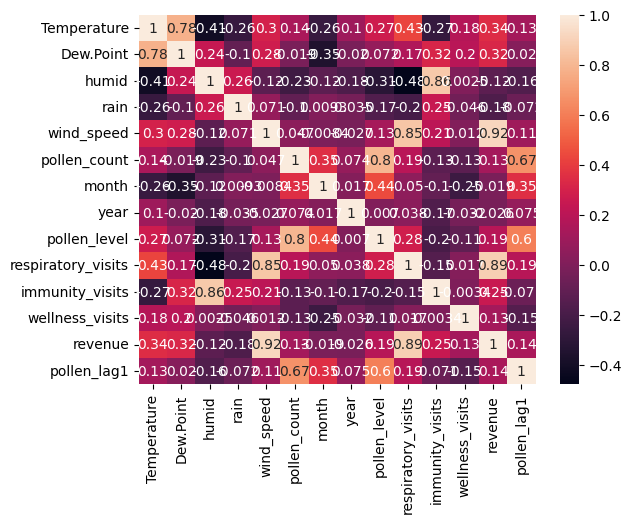

In [46]:
#visualization
sns.heatmap(clinic_df.corr(numeric_only=True),annot=True)

<Axes: xlabel='season', ylabel='revenue'>

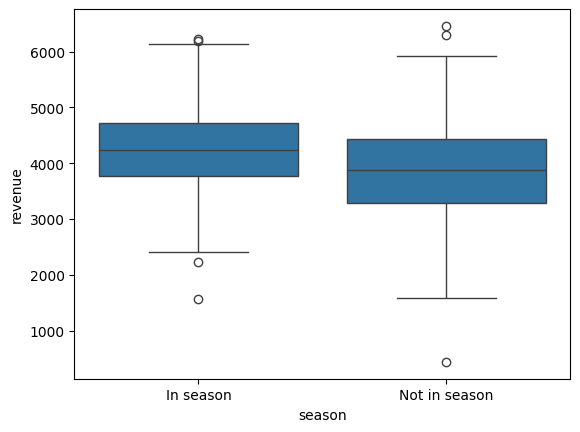

In [47]:
sns.boxplot(x='season', y= 'revenue',data=clinic_df)

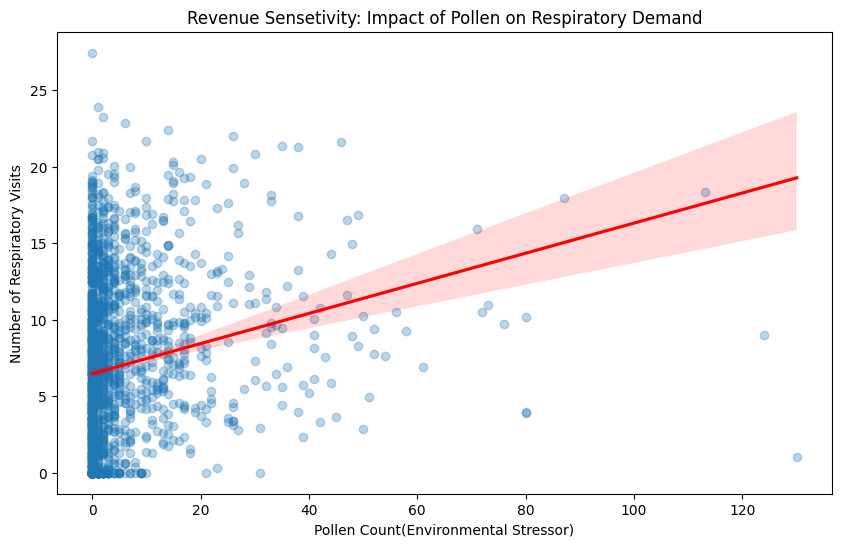

In [48]:
#scatter plot with confidence interval and regression line for revenue sensetivity
plt.figure(figsize=(10,6))
sns.regplot(data=clinic_df, x="pollen_count", y= "respiratory_visits",
            scatter_kws={'alpha':0.3},line_kws={'color':'red'})
plt.title("Revenue Sensetivity: Impact of Pollen on Respiratory Demand")
plt.xlabel("Pollen Count(Environmental Stressor)")
plt.ylabel("Number of Respiratory Visits")
plt.show()

In [49]:
monthly_pollen = df.groupby("month")["pollen_count"].mean()
monthly_pollen

,pollen_count
month,
1,2.568306
2,1.513699
3,1.142857
4,1.125874
5,0.571429
6,0.204082
7,0.236842
8,0.724138
9,6.726257


In [50]:
monthly_pollen.sort_values(ascending=False)

,pollen_count
month,
10,22.376344
11,12.082278
9,6.726257
12,5.497175
1,2.568306
2,1.513699
3,1.142857
4,1.125874
8,0.724138


The dataset shows pollen levels are highest during october and november

Provide clear visualizations that a Finance Analyst can present to stakeholders to justify a 20% shift in the annual marketing budget toward high-pollution/high-pollen months.

In [51]:
#20% shift
peak_months =[9,10,11]
months = np.arange(1,13)
current_budget = np.ones(12) * 100
proposed_budget = np.ones(12) * 100

#calculate total shift amount
shift_amount = 20
#add to peak months
for m in peak_months:
  proposed_budget[m-1] += shift_amount
#keeping total budget constant

total_added = shift_amount * len(peak_months)
reduction = total_added /12
proposed_budget-=reduction

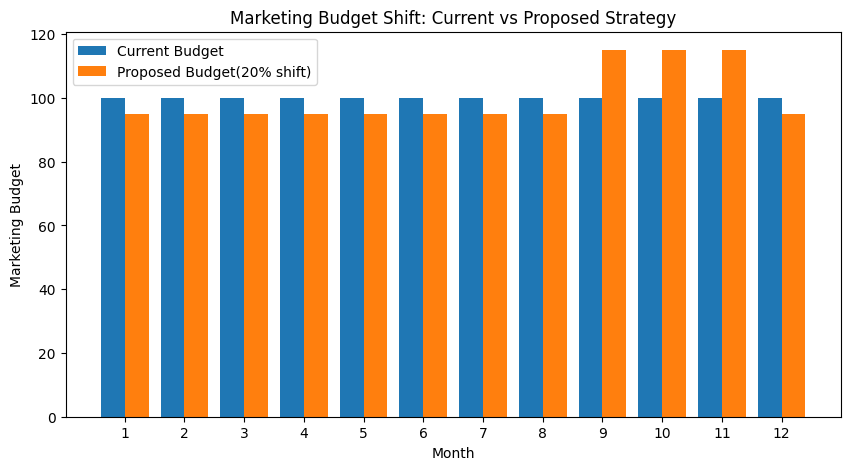

In [52]:
plt.figure(figsize=(10,5))
plt.bar(months - 0.2, current_budget, width=0.4, label="Current Budget")
plt.bar(months + 0.2, proposed_budget, width=0.4, label="Proposed Budget(20% shift)")
plt.xticks(months)
plt.xlabel("Month")
plt.ylabel("Marketing Budget")
plt.title("Marketing Budget Shift: Current vs Proposed Strategy")
plt.legend()
plt.show()

High pollen months identified(september, October and november)
made 20% shift on the budget
Visualize the bar graph to show the change.
And put future recommendation.